In [8]:
# === Imports ===
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error # 성능 비교를 위해 추가

warnings.filterwarnings("ignore")

# ARIMA
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    _HAS_ARIMA = True
except Exception as e:
    print("[WARN] statsmodels가 없어 ARIMA를 건너뜁니다:", e)
    _HAS_ARIMA = False

# === Paths & Params ===
INPUT_PATH = "../data/export_value.csv"        # 필요 시 수정
OUT_DIR    = "../output/problem1_surprise"     # 결과 저장 폴더
os.makedirs(OUT_DIR, exist_ok=True)

# 기본 하이퍼파라미터
SMA_WINDOW   = 3
EWMA_SPAN    = 3
ARIMA_ORDER  = (1, 2, 1)
REFIT_EVERY  = 3   # ARIMA: refit 주기


# === Utilities (변경 없음) ===
def _finish_and_save(df, out_path, method_name):
    """
    df: columns = [date, symbol, export_value, forecast]
    out_path: csv path to save
    """
    out = df.copy()
    # surprise 계산
    out["surprise"] = out["export_value"] - out["forecast"]
    out["surprise_pct"] = np.where(out["forecast"].abs() > 1e-12,
                                   (out["surprise"] / out["forecast"]) * 100.0,
                                   np.nan)
    # z-score는 심볼별 표준화
    out["surprise_z"] = (
        out.groupby("symbol")["surprise"]
           .transform(lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) else np.nan))
    )
    # 컬럼 순서 정리
    out = out[["date", "symbol", "export_value", "forecast", "surprise", "surprise_pct", "surprise_z"]]
    out.sort_values(["symbol", "date"], inplace=True)
    out.to_csv(out_path, index=False)
    print(f"[OK] {method_name} 결과 저장: {out_path}")
    return out


def _prepare(input_path=INPUT_PATH):
    """
    export_value.csv 읽고 기본 전처리
    """
    df = pd.read_csv(input_path)
    # date 파싱 & 정렬
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
    # 숫자 변환 (혹시 문자열일 수 있음)
    df["export_value"] = pd.to_numeric(df["export_value"], errors="coerce")
    # 월별 데이터라고 가정, symbol/date 중복 제거(있다면 평균)
    df = df.groupby(["symbol", "date"], as_index=False)["export_value"].mean()
    return df

# 데이터 로드 및 준비
df0 = _prepare(INPUT_PATH)
print("초기 데이터 로드 완료")

초기 데이터 로드 완료


In [2]:
# === 1) SMA 실행 ===
print("➡️ SMA 모델 학습 및 예측 시작...")
def surprise_sma(df, window=SMA_WINDOW):
    """
    심볼별 이동평균(window)으로 t의 forecast = 과거 window개월 평균
    """
    f = (
        df.copy()
          .assign(
              forecast = df.groupby("symbol")["export_value"]
                           .transform(lambda s: s.rolling(window, min_periods=1).mean())
                           .shift(1)
          )
    )
    return f

# 실행 및 저장
sma_df = surprise_sma(df0, window=SMA_WINDOW)
sma_df_saved = _finish_and_save(sma_df, os.path.join(OUT_DIR, "problem1_surprise_sma.csv"), "SMA")

➡️ SMA 모델 학습 및 예측 시작...
[OK] SMA 결과 저장: ../output/problem1_surprise/problem1_surprise_sma.csv


In [3]:
# === 2) EWMA 실행 ===
print("➡️ EWMA 모델 학습 및 예측 시작...")
def surprise_ewma(df, span=EWMA_SPAN):
    """
    심볼별 EWMA(span)으로 t의 forecast = 과거 EWMA
    """
    f = (
        df.copy()
          .assign(
              forecast = df.groupby("symbol")["export_value"]
                           .transform(lambda s: s.ewm(span=span, adjust=False).mean())
                           .shift(1)
          )
    )
    return f

# 실행 및 저장
ewma_df = surprise_ewma(df0, span=EWMA_SPAN)
ewma_df_saved = _finish_and_save(ewma_df, os.path.join(OUT_DIR, "problem1_surprise_ewma.csv"), "EWMA")

➡️ EWMA 모델 학습 및 예측 시작...
[OK] EWMA 결과 저장: ../output/problem1_surprise/problem1_surprise_ewma.csv


In [4]:
# === 3) ARIMA 실행 ===
if _HAS_ARIMA:
    print("➡️ ARIMA 모델 학습 및 예측 시작 (반복 재학습으로 시간이 걸릴 수 있습니다)...")
    
    def _arima_one_step_series(y: pd.Series, order=ARIMA_ORDER, refit_every=REFIT_EVERY):
        """
        y: 시계열(시간순), 각 시점에서 과거 데이터만 사용하여 1스텝 예측.
        """
        y = y.astype(float)
        idx = y.index
        fc = pd.Series(index=idx, dtype=float)

        start = 1
        last_fit_i = None
        model = None
        results = None

        for i in range(start, len(y)):
            if (results is None) or (i - (last_fit_i or 0) >= refit_every):
                train = y.iloc[:i]
                if train.notna().sum() < max(order[1] + 1, 5):
                    fc.iloc[i] = np.nan
                    continue
                try:
                    model = SARIMAX(train, order=order, enforce_stationarity=False, enforce_invertibility=False)
                    results = model.fit(disp=False)
                    last_fit_i = i
                except Exception:
                    fc.iloc[i] = np.nan
                    continue

            # 1-step ahead forecast
            try:
                pred = results.get_forecast(steps=1)
                fc.iloc[i] = float(pred.predicted_mean.iloc[0])
            except Exception:
                fc.iloc[i] = np.nan
        return fc


    def surprise_arima(df, order=ARIMA_ORDER, refit_every=REFIT_EVERY):
        """
        심볼별 ARIMA rolling one-step ahead 예측
        """
        out_list = []
        for sym, g in df.groupby("symbol", sort=False):
            g = g.sort_values("date").reset_index(drop=True)
            y = g["export_value"]
            fc = _arima_one_step_series(y, order=order, refit_every=refit_every)
            g["forecast"] = fc.values
            g["symbol"] = sym
            out_list.append(g)
        f = pd.concat(out_list, axis=0, ignore_index=True)
        return f

    # 실행 및 저장
    arima_df = surprise_arima(df0, order=ARIMA_ORDER, refit_every=REFIT_EVERY)
    arima_df_saved = _finish_and_save(arima_df, os.path.join(OUT_DIR, "problem1_surprise_arima.csv"), "ARIMA")
else:
    print("[SKIP] ARIMA 결과 미생성(statsmodels 미설치).")

➡️ ARIMA 모델 학습 및 예측 시작 (반복 재학습으로 시간이 걸릴 수 있습니다)...


/Users/masterj/Documents/GitHub/StockPlay-Data-analysis/5mil/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/masterj/Documents/GitHub/StockPlay-Data-analysis/5mil/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/masterj/Documents/GitHub/StockPlay-Data-analysis/5mil/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/masterj/Documents/GitHub/StockPlay-Data-analysis/5mil/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to c

[OK] ARIMA 결과 저장: ../output/problem1_surprise/problem1_surprise_arima.csv


In [7]:
# === 5) 모델 성능 비교 분석 ===
print("\n" + "="*40)
print("📊 세 모델 성능 비교 (RMSE, MAE)")
print("="*40)

# 비교에 사용할 모델과 해당 결과 DataFrame
# 각 모델 실행 블록에서 저장된 DataFrame 변수를 사용합니다.
all_models = {
    "SMA": sma_df_saved,
    "EWMA": ewma_df_saved,
    "ARIMA": arima_df_saved if _HAS_ARIMA else None
}

performance_metrics = {}

for model_name, df_result in all_models.items():
    if df_result is not None:
        # forecast 컬럼에 NaN 값이 있는 행은 제외 (예: 첫 예측 시점)
        df_clean = df_result.dropna(subset=['forecast'])
        
        y_true = df_clean['export_value']
        y_pred = df_clean['forecast']
        
        if len(y_true) > 0:
            # RMSE 계산
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            
            # MAE 계산
            mae = mean_absolute_error(y_true, y_pred)
            
            performance_metrics[model_name] = {'RMSE': rmse, 'MAE': mae}
        else:
            print(f"⚠️ {model_name} 모델은 유효한 예측 데이터가 충분하지 않아 비교에서 제외합니다.")

if performance_metrics:
    # 결과를 DataFrame으로 변환 및 RMSE 기준으로 정렬
    df_results = pd.DataFrame(performance_metrics).T 
    df_results = df_results.sort_values(by='RMSE')

    print(df_results.to_markdown(floatfmt=".2f"))
    print("="*40)

    best_model = df_results.index[0]
    print(f"✨ 가장 낮은 RMSE를 보인 모델: **{best_model}**")
else:
    print("분석 가능한 유효한 모델 결과가 없습니다.")


📊 세 모델 성능 비교 (RMSE, MAE)
|       |        RMSE |         MAE |
|:------|------------:|------------:|
| ARIMA | 74577004.24 | 14948355.35 |
| SMA   | 81055351.87 | 13012123.22 |
| EWMA  | 82049834.63 | 13206728.94 |
✨ 가장 낮은 RMSE를 보인 모델: **ARIMA**


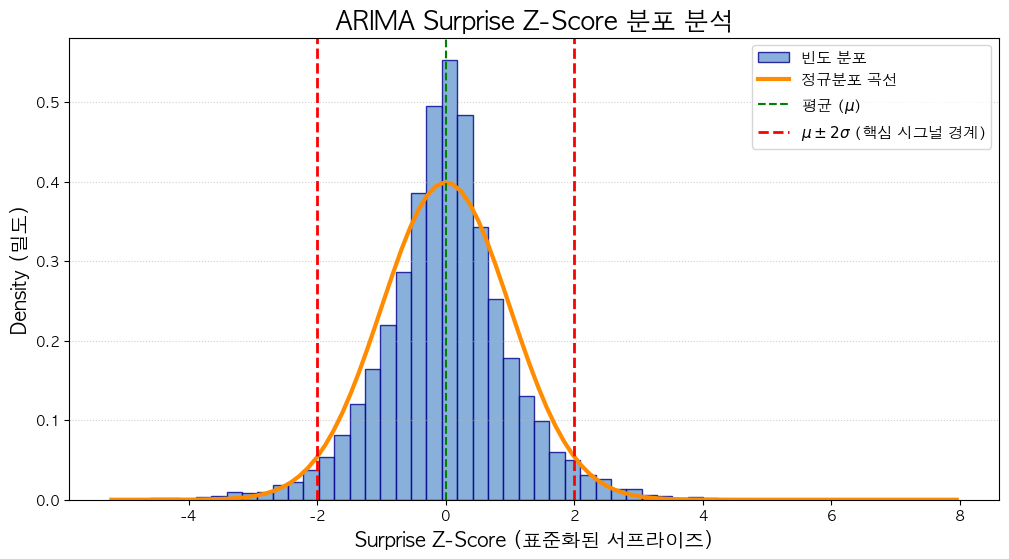


✅ 시각화 완료: ../output/problem1_surprise/problem1_surprize_arima_z.png
   Mean of Z-Score: 0.0000
   Std Dev of Z-Score: 1.0000


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import platform
from matplotlib import font_manager, rc

# --- 1. Matplotlib 한글 폰트 설정 (필수) ---
if platform.system() == 'Darwin': 
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows': 
    font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
    rc('font', family=font_name)
elif platform.system() == 'Linux': 
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False 


# --- 2. 데이터 로드 및 시각화 ---
OUT_DIR = "../output/problem1_surprise"
FILE_NAME = "problem1_surprise_arima.csv"
file_path = os.path.join(OUT_DIR, FILE_NAME) 
# !!!!!!!! 파일 경로를 다시 한번 확인하고 수정하세요 !!!!!!!!!

try:
    df_arima = pd.read_csv(file_path)
    z_scores = df_arima['surprise_z'].dropna()
    
    if len(z_scores) > 5:
        # Z-score의 통계량 계산
        mean_z = z_scores.mean()
        std_z = z_scores.std()

        plt.figure(figsize=(12, 6)) 
        
        # 히스토그램 플로팅 (색상 변경: 하늘색 계열, 테두리 진하게)
        plt.hist(z_scores, bins=50, color='#6B9CD2', edgecolor='darkblue', alpha=0.8, density=True, label='빈도 분포')
        
        # 정규분포 곡선 추가 (색상 변경: 주황색 계열로 대비 강조)
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = (1/(std_z * np.sqrt(2 * np.pi))) * np.exp(-(x - mean_z)**2 / (2 * std_z**2))
        plt.plot(x, p, color='darkorange', linewidth=3, label='정규분포 곡선')

        # 주요 표준편차 라인 추가 (±2 시그마)
        plt.axvline(mean_z, color='green', linestyle='--', linewidth=1.5, label='평균 ($\mu$)')
        plt.axvline(mean_z + 2 * std_z, color='red', linestyle='--', linewidth=2, label='$\mu \pm 2\sigma$ (핵심 시그널 경계)')
        plt.axvline(mean_z - 2 * std_z, color='red', linestyle='--', linewidth=2)
        
        # 차트 꾸미기
        plt.title('ARIMA Surprise Z-Score 분포 분석', fontsize=18)
        plt.xlabel('Surprise Z-Score (표준화된 서프라이즈)', fontsize=14)
        plt.ylabel('Density (밀도)', fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(axis='y', linestyle=':', alpha=0.6)
        
        plot_path = os.path.join(OUT_DIR, "problem1_surprize_arima_z.png")
        plt.savefig(plot_path)
        plt.show()
        
        print(f"\n✅ 시각화 완료: {plot_path}")
        print(f"   Mean of Z-Score: {mean_z:.4f}")
        print(f"   Std Dev of Z-Score: {std_z:.4f}")
    else:
        print("❌ 오류: 유효한 데이터 포인트가 부족하여 히스토그램을 생성할 수 없습니다.")
except FileNotFoundError:
    print(f"❌ 오류: 파일 경로를 다시 확인해주세요. {FILE_NAME} 파일을 찾을 수 없습니다.")

In [27]:
import pandas as pd
import os
import numpy as np

# --- 설정 ---
OUT_DIR = "../output/problem1_surprise"
FILE_NAME = "problem1_surprise_arima.csv"
file_path = os.path.join(OUT_DIR, FILE_NAME) 

try:
    df_arima = pd.read_csv(file_path)
    z_scores = df_arima['surprise_z'].dropna()
    
    if len(z_scores) > 5:
        # Z-score의 통계량 계산
        mean_z = z_scores.mean()
        std_z = z_scores.std()

        # --- 양/음 시그널 비율 계산 ---
        # Z > +2sigma (양의 시그널)
        positive_signal_count = z_scores[z_scores > mean_z + 2 * std_z].count()
        # Z < -2sigma (음의 시그널)
        negative_signal_count = z_scores[z_scores < mean_z - 2 * std_z].count()
        
        total_count = len(z_scores)
        
        positive_signal_percent = (positive_signal_count / total_count) * 100
        negative_signal_percent = (negative_signal_count / total_count) * 100
        
        normal_range_percent = 100 - (positive_signal_percent + negative_signal_percent)
        # ----------------------------
        
        # --- 결과 출력 ---
        print("\n" + "="*60)
        print("ARIMA Surprise Z-Score (±2σ) 양/음 시그널 분포 분석")
        print("="*60)
        print(f"Total Data Points (유효값): {total_count}개")
        print(f"Mean (평균) of Z-Score: {mean_z:.4f}")
        print(f"Std Dev (표준편차) of Z-Score: {std_z:.4f}")
        print("-"*60)
        print("시그널 발생 빈도 (±2$\sigma$ 경계 기준):")
        print(f" - 양의 시그널 ($Z > +2\sigma$, 매수/Long): {positive_signal_percent:.2f}%")
        print(f" - 음의 시그널 ($Z < -2\sigma$, 매도/Short): {negative_signal_percent:.2f}%")
        print(f" - 일반 범위 ($|Z| \le 2\sigma$, 대기): {normal_range_percent:.2f}%")
        print("-"*60)
        print(f"   [총 시그널 빈도: {(positive_signal_percent + negative_signal_percent):.2f}%]")
        print("="*60)
        
    else:
        print("오류: 유효한 데이터 포인트가 부족하여 시그널 비율을 계산할 수 없습니다.")
except FileNotFoundError:
    print(f"오류: 파일 경로를 다시 확인해주세요. {FILE_NAME} 파일을 찾을 수 없습니다.")


ARIMA Surprise Z-Score (±2σ) 양/음 시그널 분포 분석
Total Data Points (유효값): 20921개
Mean (평균) of Z-Score: 0.0000
Std Dev (표준편차) of Z-Score: 1.0000
------------------------------------------------------------
시그널 발생 빈도 (±2$\sigma$ 경계 기준):
 - 양의 시그널 ($Z > +2\sigma$, 매수/Long): 2.86%
 - 음의 시그널 ($Z < -2\sigma$, 매도/Short): 2.76%
 - 일반 범위 ($|Z| \le 2\sigma$, 대기): 94.38%
------------------------------------------------------------
   [총 시그널 빈도: 5.62%]
